In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

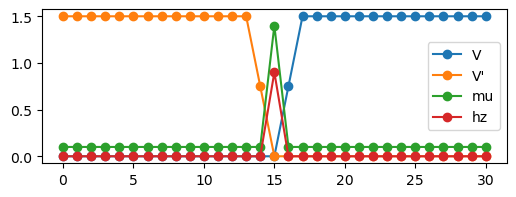

In [7]:
widthD = 15
widthF = 1
widthP = 15

X, Y = widthD+widthF+widthP, 50
lattice = Lattice(X, Y)

t = 1
T = 0.1

muD = 0.1 * t
muP = 0.1 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthP] = muP
mu[widthP:widthP + widthF] = muF
mu[widthP + widthF:] = muD

h0 = +0.9 * t
h = np.zeros_like(mu)
h[widthP:widthP + widthF] = h0

U = None

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[widthP:] = 0
V_prime[widthP-1] = V_prime0/2

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthF+widthP] = 0 
V[widthF+widthP] = V0/2


plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [8]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=h)

In [11]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, verbose=False, temperature=T)

Converged after 693 iterations


In [ ]:
F, Fuu, Fdd = H.get_correlations()

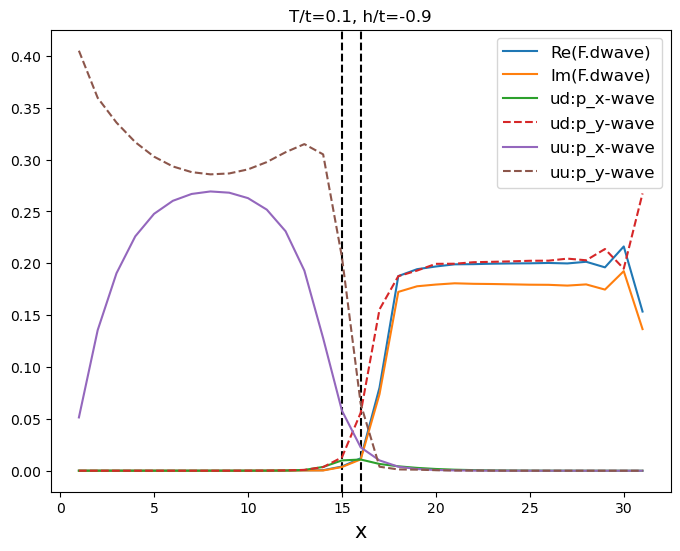

In [6]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()

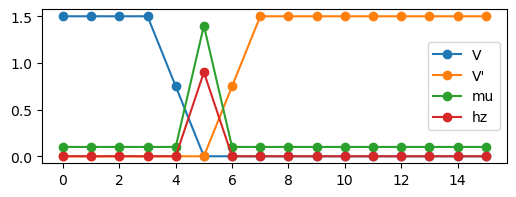

In [ ]:
widthD = 5
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.5

muD = 0.1 * t
muP = 0.1 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0 
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [ ]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=h)

In [ ]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=1000, verbose=False, temperature=T)
F2, Fuu2, Fdd2 = H.get_correlations()

Converged after 126 iterations


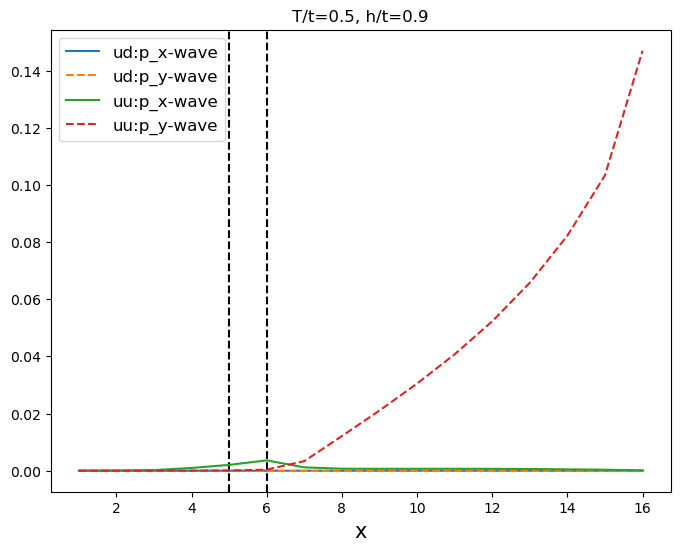

In [ ]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
# axs.plot(x, np.real(F2.dwave), label="Re(F.dwave)")
# axs.plot(x, np.imag(F2.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F2.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F2.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu2.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu2.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()

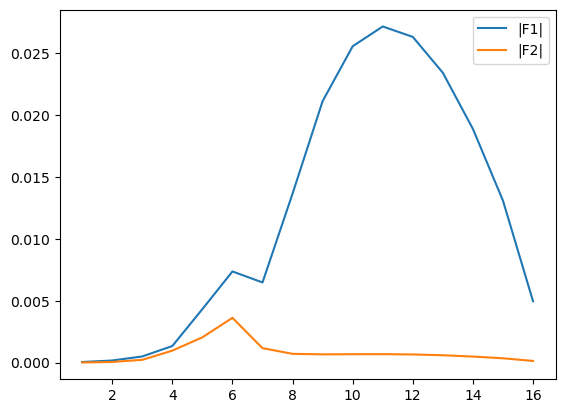

In [ ]:
plt.figure()
# plt.plot(x, np.real(F.dwave), label="Re(F.dwave)")
# plt.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
plt.plot(x, np.abs(Fuu.px), label="|F1|")
plt.plot(x, np.abs(Fuu2.px), label="|F2|")
plt.legend()